In [257]:
import math
import random
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
from tictactoeenv import TicTacToeEnv
from tqdm import tqdm

## Hyperparameters

In [282]:
INF = float("inf")

EPOCHS = 100_000

ALPHA = 0.5
GAMMA = 0.9

LAMBDA = 5 / EPOCHS
EPSILON_MIN, EPSILON_MAX = 0.5, 1
epsilon = lambda epoch: (
    EPSILON_MIN + (EPSILON_MAX - EPSILON_MIN) * math.e ** (-LAMBDA * epoch)
)

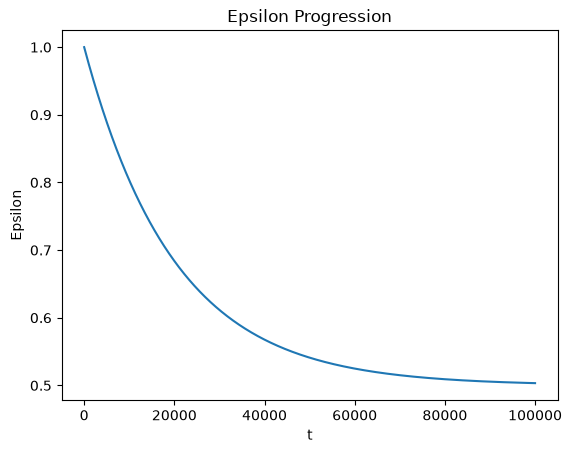

In [283]:
t = [i for i in range(EPOCHS)]
eps = [epsilon(i) for i in t]

plt.plot(t, eps)
plt.title("Epsilon Progression")
plt.xlabel("t")
plt.ylabel("Epsilon")
plt.show()

## Q-Learning Training

In [284]:
q_table = defaultdict(lambda: np.zeros(9))
env = TicTacToeEnv()

In [285]:
def random_play_win(
    env: TicTacToeEnv, q_table: defaultdict[tuple[int, ...], np.ndarray], agent: int
) -> True:
    env.reset()
    player_to_move = 1
    done = False
    while not done:
        if player_to_move == agent:
            q_values = q_table[env._get_state()].copy()
            legal_actions = env.legal_actions()
            q_values[[a for a in range(9) if a not in legal_actions]] = -INF
            action = np.argmax(q_values)
        else:
            action = random.choice(env.legal_actions())

        *_, done, info = env.step(action)
        player_to_move = info.get("player_who_moved") * (-1)

    return info["winner"] == agent

In [286]:
def validate(
    env: TicTacToeEnv, q_table: defaultdict[tuple[int, ...], np.ndarray], val_size: int
) -> None:
    agent = 1
    player_1_w = np.array(
        [random_play_win(env, q_table, agent) for _ in range(val_size)]
    )

    agent = -1
    player_2_w = np.array(
        [random_play_win(env, q_table, agent) for _ in range(val_size)]
    )

    p1_winrate = player_1_w.mean()
    p2_winrate = player_2_w.mean()

    return p1_winrate, p2_winrate

### How the training loop works

**One Q-table for both players.** A state $s$ is the board (9 cells: `1` = X, `-1` = O, `0` = empty). Whose turn it is follows from the pieces on the board: X moves when both have the same number of pieces, O moves when X has one more. So every state belongs to exactly one player, and X's and O's entries never collide in the table.

$Q(s, a)$ is always from the view of **the player to move in $s$**: how good is move $a$ for *me*? $+1$ means I win, $0$ means a draw, $-1$ means I lose. That is why one table works for both players, and why the board visualization shows green as "good for whoever's turn it is".

**Each step of an episode:**

1. **Choose a move (ε-greedy).** With probability $\varepsilon(\text{epoch})$ play a random legal move (explore). Otherwise play $\arg\max_a Q(s, a)$ (exploit). Occupied cells are set to $-\infty$ so they are never picked.
   $$\varepsilon(\text{epoch}) = \varepsilon_{\min} + (\varepsilon_{\max} - \varepsilon_{\min}) \cdot e^{-\lambda \cdot \text{epoch}}$$
2. **Play it:** `env.step(action)` returns `next_state`, `reward`, `done`. The reward is from the view of **the player who just moved**:
   - $r = +1$: this move won the game
   - $r = 0$: draw, or the game continues
   - $r = -1$ is possible in the env's API but can't happen in tic-tac-toe: your own move can never make you lose.
3. **Compute the target**, i.e. what $Q(s, a)$ should be:
   - **Game over:** $\text{target} = r$. The game is decided, so there is nothing more to add.
   - **Game continues:** $\text{target} = r - \gamma \cdot \max_{a'} Q(s', a')$
4. **Update:** move $Q(s, a)$ a step of size $\alpha$ toward the target:
   $$Q(s, a) \leftarrow Q(s, a) + \alpha \cdot \big(\text{target} - Q(s, a)\big)$$

**Why the minus sign?** Standard single-agent Q-learning uses $r + \gamma \max_{a'} Q(s', a')$. Here, though, $s'$ belongs to the **opponent**. $\max_{a'} Q(s', a')$ is the value of the opponent's best reply *from their view*. It's a zero-sum game, so their gain is my loss, and the value of that position for me is $-\max_{a'} Q(s', a')$. This is called *negamax*. The sign flips automatically every move, so X's and O's values stay consistent in the shared table without tracking whose turn it is.

**Example.** Board `X X . / . O . / . . .`, O to move:
- O plays cell 3 (doesn't block). X's best reply (cell 2) wins, so $\max_{a'} Q(s', a') = 1$ and $\text{target} = 0 - 0.9 \cdot 1 = -0.9$. This move is red on the board.
- O blocks at cell 2. With best play the game is a draw, so $\max_{a'} Q(s', a') = 0$ and $\text{target} = 0$. This move is yellow, and it's the best O can do.

**What the Q-values mean.** $Q$ is the outcome of the move with best play afterwards, not a probability. $\gamma = 0.9$ makes faster wins worth more: a win $k$ moves later is worth $\gamma^k$. Since tic-tac-toe is a draw with best play, most good moves have $Q \approx 0$ (yellow). Only forced wins approach $+1$ (green) and blunders go negative (red).

**Why a high $\varepsilon_{\min}$ is fine here.** The target uses $\max$, not the move that was actually played, so Q-learning learns the best-play values no matter how randomly we explore (it's *off-policy*). More exploration only means more positions get visited.

In [ ]:
def train(
    env: TicTacToeEnv, q_table: defaultdict[tuple[int, ...], np.ndarray]
) -> tuple[list[float], list[float]]:
    p1_wrs = []
    p2_wrs = []

    for epoch in tqdm(range(EPOCHS)):
        env.reset()
        done = False
        while not done:
            # Find next Action
            state = env._get_state()
            if random.random() < epsilon(epoch):
                action = random.choice(env.legal_actions())  # Random Action
            else:
                q_values = q_table[state].copy()
                legal_actions = env.legal_actions()
                q_values[[a for a in range(9) if a not in legal_actions]] = -INF
                action = np.argmax(q_values)

            # Play Game
            next_state, reward, done, _ = env.step(action)

            # Reward
            if done:
                target = reward  # The Player that just moved won
            else:
                next_legal_actions = env.legal_actions()
                max_next_q = max(q_table[next_state][a] for a in next_legal_actions)
                # next state belongs to the opponent, so their gain is my loss (use - instead of +)
                target = reward - GAMMA * max_next_q

            q_table[state][action] += ALPHA * (target - q_table[state][action])

        # Validation
        if (epoch + 1) % 1000 == 0:
            p1_wr, p2_wr = validate(env, q_table, 1000)
            p1_wrs.append(p1_wr)
            p2_wrs.append(p2_wr)

    return p1_wrs, p2_wrs

In [288]:
p1_wrs, p2_wrs = train(env, q_table)

100%|██████████| 100000/100000 [00:15<00:00, 6647.85it/s]


## Evaluation

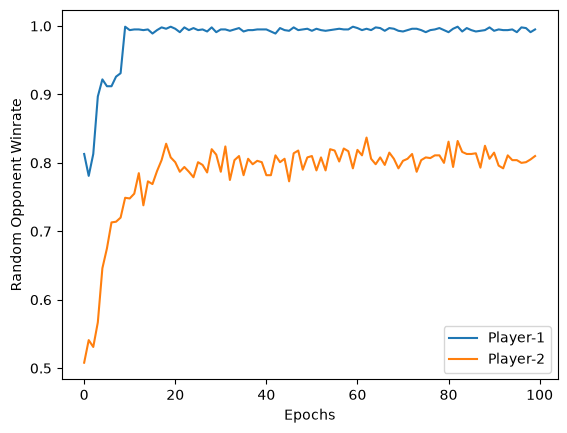

In [289]:
plt.plot(p1_wrs, label="Player-1")
plt.plot(p2_wrs, label="Player-2")
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Random Opponent Winrate")
plt.show()

## Play Game

In [280]:
import json
import uuid

from IPython.display import HTML, display

GAME_TEMPLATE = """
<div id="ttt-__UID__" style="font-family: sans-serif;"></div>
<script>
(function () {
  const Q = __QTABLE__;
  const script = document.currentScript;
  const root = (script && script.parentNode && script.parentNode.querySelector("#ttt-__UID__"))
    || document.getElementById("ttt-__UID__");
  const LINES = [[0,1,2],[3,4,5],[6,7,8],[0,3,6],[1,4,7],[2,5,8],[0,4,8],[2,4,6]];
  const SYM = {"1": "X", "-1": "O", "0": ""};
  let board, player, winner;

  function lerp(a, b, t) { return a.map((v, i) => Math.round(v + (b[i] - v) * t)); }

  function color(q) {
    const t = Math.max(-1, Math.min(1, q));
    const red = [215, 48, 39], yellow = [255, 255, 191], green = [26, 152, 80];
    const rgb = t < 0 ? lerp(yellow, red, -t) : lerp(yellow, green, t);
    return "rgb(" + rgb.join(",") + ")";
  }

  function checkWinner() {
    for (const [a, b, c] of LINES) {
      if (board[a] !== 0 && board[a] === board[b] && board[a] === board[c]) return board[a];
    }
    return board.includes(0) ? null : 0;
  }

  function render() {
    const q = Q[board.join(",")] || Array(9).fill(0);
    root.replaceChildren();

    const grid = document.createElement("div");
    grid.style.cssText = "display: grid; grid-template-columns: repeat(3, 70px); grid-template-rows: repeat(3, 70px); gap: 4px;";
    board.forEach((mark, i) => {
      const cell = document.createElement("button");
      cell.dataset.cell = i;
      cell.style.cssText = "width: 70px; height: 70px; padding: 0; border: 1px solid #888; border-radius: 4px; color: #222; font-weight: bold;";
      if (mark !== 0 || winner !== null) {
        cell.textContent = SYM[mark];
        cell.style.fontSize = "28px";
        cell.style.background = "#ddd";
        cell.disabled = true;
      } else {
        cell.textContent = q[i].toFixed(2);
        cell.style.fontSize = "13px";
        cell.style.background = color(q[i]);
        cell.style.cursor = "pointer";
      }
      grid.appendChild(cell);
    });

    const status = document.createElement("p");
    status.style.margin = "8px 0";
    if (winner === null) status.textContent = "Player " + SYM[player] + " to move";
    else if (winner === 0) status.textContent = "Draw!";
    else status.textContent = "Player " + SYM[winner] + " wins!";

    const resetButton = document.createElement("button");
    resetButton.dataset.action = "reset";
    resetButton.textContent = "Reset";
    resetButton.style.cssText = "padding: 4px 12px; cursor: pointer;";

    root.append(grid, status, resetButton);
  }

  function play(i) {
    if (winner !== null || board[i] !== 0) return;
    board[i] = player;
    winner = checkWinner();
    if (winner === null) player = -player;
    render();
  }

  function reset() {
    board = Array(9).fill(0);
    player = 1;
    winner = null;
    render();
  }

  root.addEventListener("click", (event) => {
    const button = event.target.closest("button");
    if (!button || !root.contains(button)) return;
    if (button.dataset.action === "reset") reset();
    else if (button.dataset.cell !== undefined) play(Number(button.dataset.cell));
  });

  reset();
})();
</script>
"""


def play_interactive(q_table: defaultdict[tuple[int, ...], np.ndarray]) -> None:
    """Render a clickable Tic Tac Toe board for two human players.

    Empty cells show the Q-value of that move for the player to move, colored
    from red (-1) over yellow (0) to green (+1). The Q-table is embedded as a
    snapshot, so re-run this after retraining.
    """
    q_json = json.dumps(
        {
            ",".join(map(str, state)): [round(float(v), 4) for v in q]
            for state, q in q_table.items()
        }
    )
    html = GAME_TEMPLATE.replace("__UID__", uuid.uuid4().hex).replace(
        "__QTABLE__", q_json
    )
    display(HTML(html))

In [281]:
play_interactive(q_table)